In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('run2025_none.csv')

LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [3]:
#alpha_gateかける
alpha_gated=df[
    (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]

<h1>gate<h1>

In [4]:
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

In [5]:
#トラッキングできたやつを抽出
tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

In [6]:
#protonゲート
proton_gated=tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
]

xdp_proton=proton_gated['GRX']
adp_proton=proton_gated['GRA']
ydp_proton=proton_gated['GRY']
bdp_proton=proton_gated['GRB']
GRQ2_proton=proton_gated['GRQ2charge']

In [7]:
#合わせる

gated = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]

GRX_gated = gated['GRX']
LASX_gated = gated['LASX']
print(GRX_gated)

79         76.6026
85        254.6680
242       441.3170
402       -34.5970
590        58.1263
            ...   
546736    -15.0700
546858   -474.1850
547010    456.0580
547230    -72.4815
547924    183.8910
Name: GRX, Length: 2186, dtype: float64


In [8]:
p = []
for n in GRX_gated:
    p.append((n * -0.0000454324 + 0.0027089081 + 1) * 832) #修正済み

Tp = []
for n in p:
    Tp.append((n ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

print(p)
print(Tp)

[831.3582518889523, 824.6274230744575, 817.5721362674944, 835.5615697252097, 832.0566515355163, 818.4241805855232, 849.3858857808897, 823.3760999253504, 853.3648771804416, 833.1731051523609, 850.7994832859392, 823.9617315574528, 827.9012600109056, 824.8073121170688, 845.836035020288, 829.3067305682432, 829.3064281701887, 820.555557672448, 827.8934732610048, 838.1060225544448, 831.6600564871706, 820.4573161045248, 847.8153436856064, 829.5790778159873, 839.305938034304, 839.1736388855039, 826.329848521216, 830.5201670211097, 820.5982335978753, 819.6033439988993, 828.2627012854272, 852.3279164521472, 821.0325528035072, 824.6257598851585, 828.4693903556097, 851.7077736420864, 814.4247017177856, 847.2413165788416, 829.4317343639808, 825.1651624146944, 830.3207090444032, 818.5162985928448, 840.4720983313407, 823.242175387008, 834.9855732511154, 824.8915299752192, 816.3678360158465, 846.7611084684544, 850.0940264247808, 821.150903842048, 835.3050378957107, 827.4648996184063, 840.988594208256,

In [9]:
T_alpha = []
for n in Tp:
    T_alpha.append((392 - n - 7.37)) #修正済み

print(T_alpha)

[69.30232295849612, 73.75590111211739, 78.40219329201125, 66.51083668249646, 68.83905081750697, 77.8422775360633, 57.274867559992465, 74.58161319786666, 54.60105791056106, 68.09801719584982, 56.325740961225286, 74.1952598908116, 71.59224839464639, 73.63713934104965, 59.654500883204385, 70.6619051211593, 70.66210538716075, 76.44020677474634, 71.59740031910349, 64.81721339888293, 69.10215247582926, 76.50487787803024, 58.32835320068046, 70.48152391062843, 64.01753903724477, 64.1057399636992, 72.63138427892397, 69.85796529854122, 76.41211241987878, 77.06685130223889, 71.35307908946822, 55.29853658034211, 76.12614493925014, 73.75699907249407, 71.21628449668026, 55.715433891984624, 80.46763255777012, 58.7131303409891, 70.57911665178983, 73.40084507316749, 69.99015776553154, 77.78172290254645, 63.239751768959316, 74.66994418659613, 66.89382945883028, 73.58153414557353, 79.19302623922056, 59.03490921114315, 56.79951162512533, 76.04820456454706, 66.68142855872622, 71.88091421413594, 62.89507600

<h1>線形フィッティング<h1>

In [10]:
gated_1 = gated[
    (LASX_gated >= -210) & (LASX_gated <= -190)
]


In [11]:
GRX_gated_1 = gated_1['GRX']

T_alpha_test = []
for n in GRX_gated_1:
    T_alpha_test.append((392 - ((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 7.37))
print(T_alpha_test)

[57.028769355183506, 67.98343475559693, 57.03450955782626, 58.41925481268175, 52.69270013579251, 57.658046749208445, 59.48431758827713, 64.49897563659022, 58.38326110370543, 71.76583306826626, 73.86065116659972, 76.31304048300615, 61.253419973303046, 69.91341238655093, 66.92078971481817, 57.948472675588285, 58.15844324854027, 58.314796032678835, 56.05110114638172, 52.67663217416101, 58.867130645610935, 66.32455183911418, 58.25053772552645, 77.8306011817159, 69.99122349732045, 56.934127634702584, 66.67367455486612, 57.72305258720724, 57.54777370756813, 57.15910985098515, 74.87497340049697, 59.05501265053534, 75.67805243128089, 70.21446675397476, 64.12624140458286, 57.74886595599913, 57.71617398995466, 64.95414175853796, 63.0793013750066, 64.32485683877223, 52.69958633034265, 57.454423379418934, 56.882307258199155, 60.368744696770484, 61.189623688784316, 61.189775468979526]


Text(0, 0.5, 'counts')

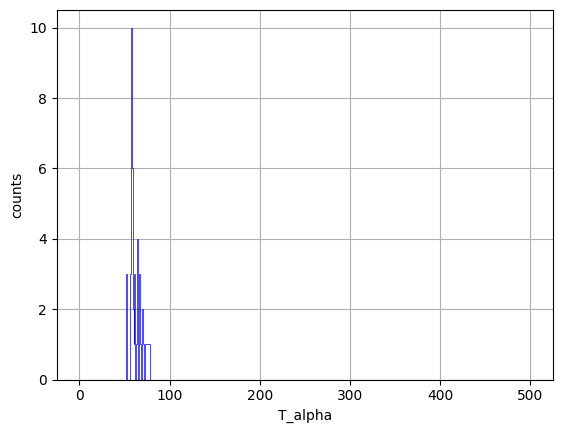

In [12]:
variables = T_alpha_test

#hist range
range_min=0
range_max=500
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('T_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 21.156 ± 2.145
Mean: 58.312 ± 0.435
Sigma: 2.205 ± 0.264


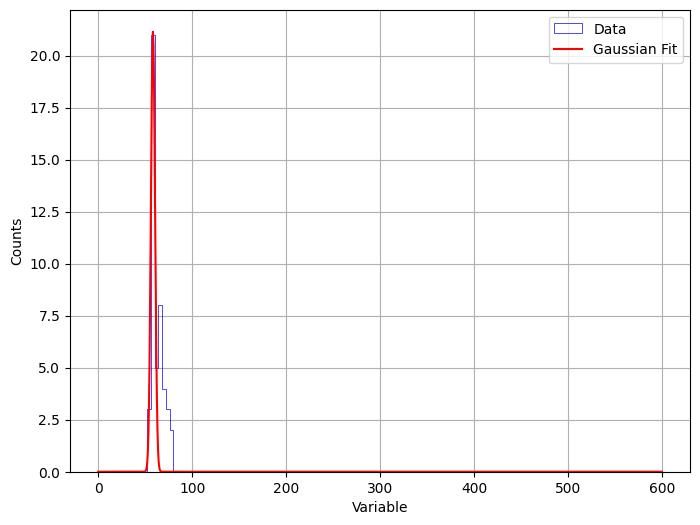

In [13]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = T_alpha_test
# Histogram range
hist_range_min = 0
hist_range_max = 600
# Bin width
bin_width = 4
# Fit range
fit_range_min = 0
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 10
mean = 50
sigma = 1
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [14]:
#gatedのLASXの値で絞り込む
gated_2 = gated[
    (LASX_gated >= 390) & (LASX_gated <= 410)
]

#gatedのGRXからT_alphaを求める
GRX_gated_2 = gated_2['GRX']

T_alpha_test2 = []
for n in GRX_gated_2:
    T_alpha_test2.append((392 - ((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 7.37))
print(T_alpha_test2)
print(len(T_alpha_test2))

[56.50767578358762, 72.89538832538335, 76.88499265527946, 74.98646507727324, 60.56480634912271, 74.00519883349, 73.75369991855666, 73.85021132884242, 75.85049114579726, 74.14830164420835, 72.9869108643137, 72.09899519053295, 73.86237447823316, 73.07907464271864, 72.64179998201337, 72.72224432971291, 67.95186816667831, 77.00112924462485, 80.63733491776645, 75.36662186064348, 77.76943886753259, 72.34542115235274, 80.81023530927234, 68.24589369580019, 73.16458138170572, 74.86207455695705, 73.2206403072106, 72.92286349512972, 61.801443052718135, 80.1153901522747, 76.0597039266903, 74.26035195952124, 74.276579199597, 73.84229396026774, 54.55220072323221, 78.25064644413817, 74.64446466391371, 79.37324842042688]
38


In [23]:
LASX_gated

79        181.97800
85        153.15500
242       366.13200
402       145.40100
590         1.00431
            ...    
546736    131.12900
546858   -445.83700
547010    557.11400
547230    129.08600
547924    333.56000
Name: LASX, Length: 2186, dtype: float64

Fitting parameters and their uncertainties:
Amp: 25.054 ± 2.270
Mean: 74.788 ± 0.289
Sigma: 1.903 ± 0.214


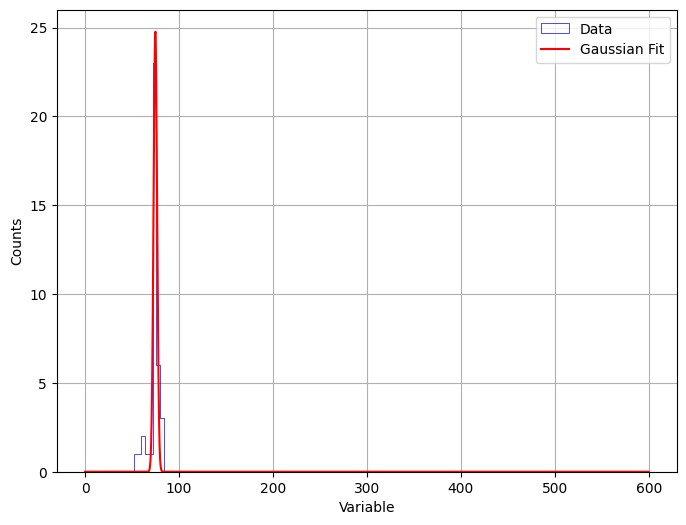

In [15]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = T_alpha_test2
# Histogram range
hist_range_min = 0
hist_range_max = 600
# Bin width
bin_width = 4
# Fit range
fit_range_min = 30
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 25
mean = 70
sigma = 1
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Weighted linear fit: y_axsis_variable = 0.0274600000 * x_axsis_variable + 63.8040000000


/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_965/2334395381.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')


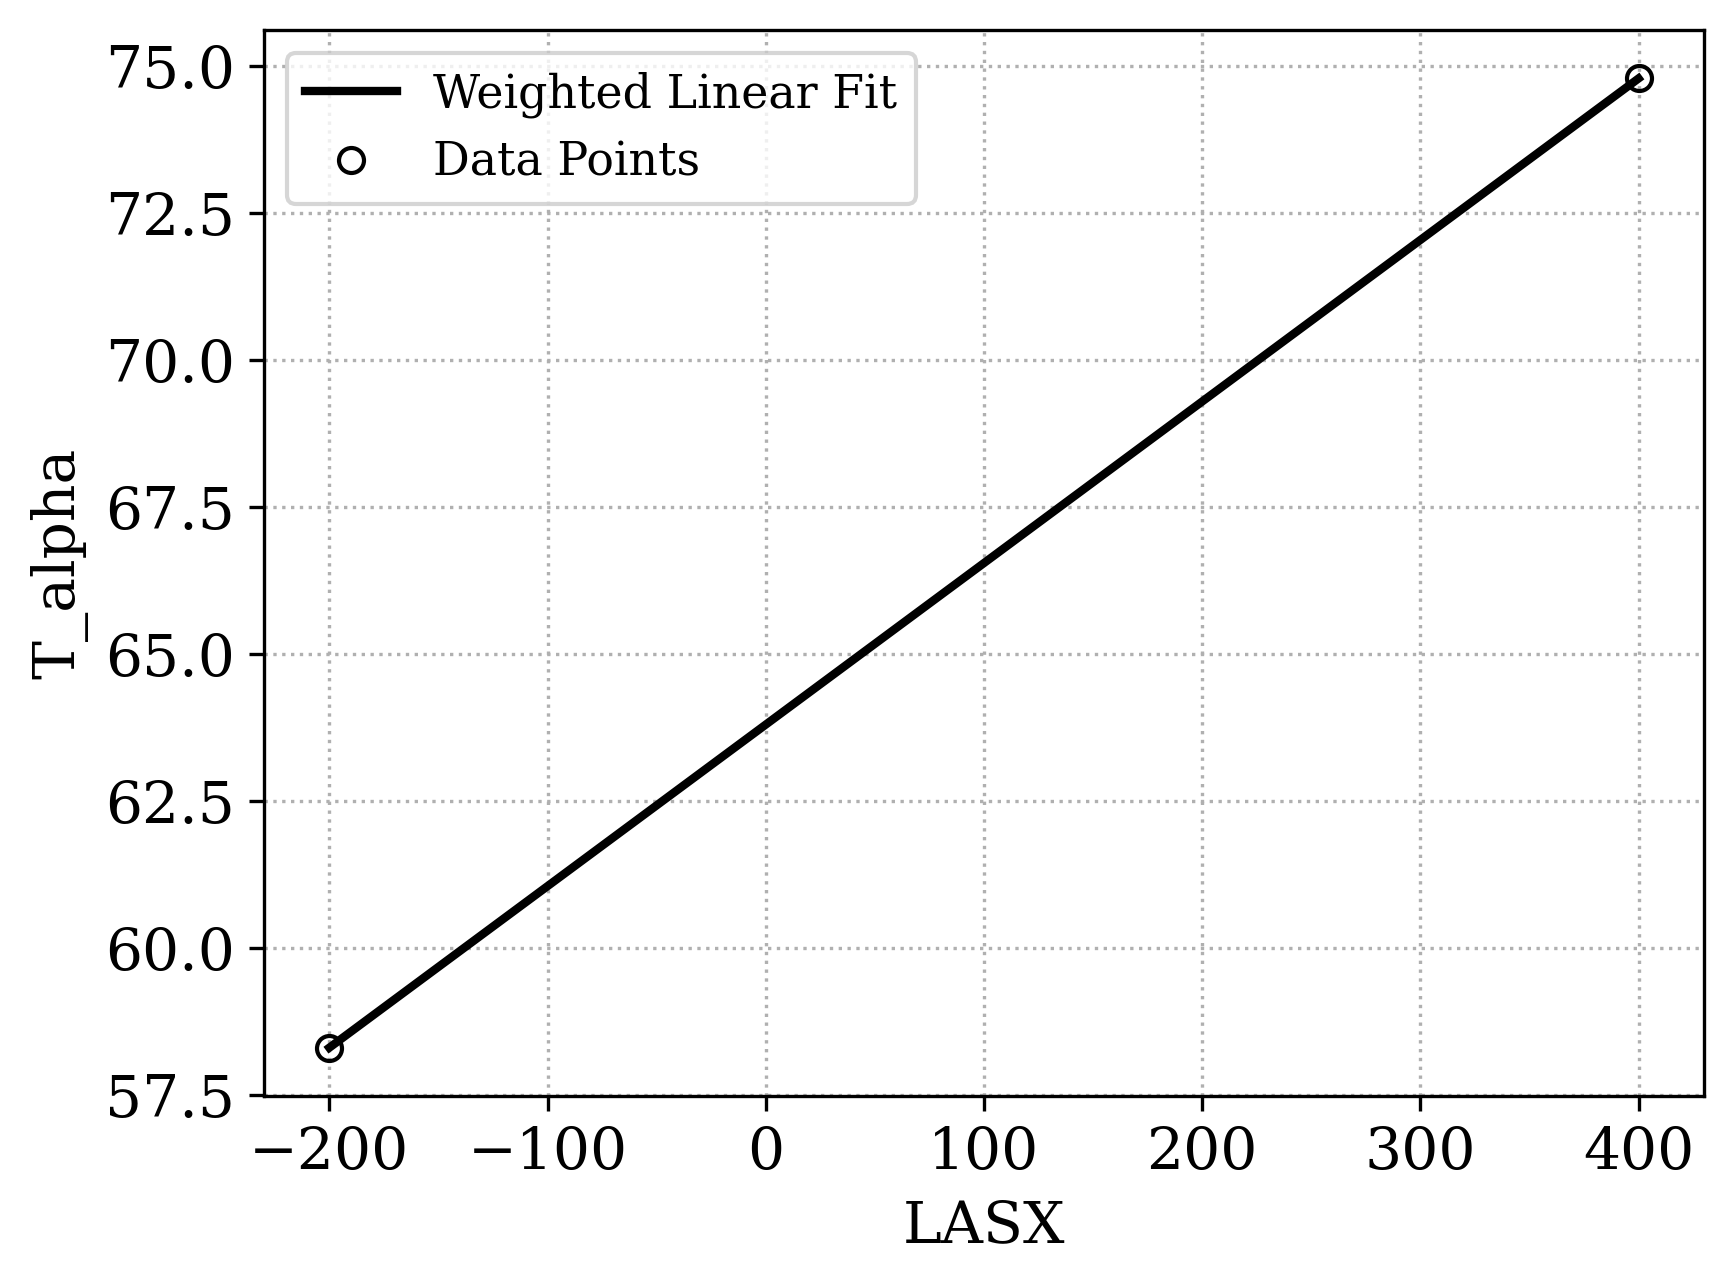

In [16]:
# # inpiut###############################
x_axis_variable = np.array([-200, 400])
y_axis_variable = np.array([58.312, 74.788])

# y_axis_variable = delta
# x_axis_variable = GRX_list


# hist_range_min=-0.011
# hist_range_max=0.0009
#######################################


# ---------- 線形フィット ----------
coefficients_linear = np.polyfit(x_axis_variable, y_axis_variable, 1)
fit_func_linear = np.poly1d(coefficients_linear)
a_linear, b_linear = coefficients_linear

print(f"Weighted linear fit: y_axsis_variable = {a_linear:.10f} * x_axsis_variable + {b_linear:.10f}")

# ---------- 描画用 ----------
x_fit = np.linspace(min(x_axis_variable), max(x_axis_variable),1001)
y_fit_linear = fit_func_linear(x_fit)

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(6, 4.5))

# フィット直線
ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')

# エラーバー付きデータ点
ax.errorbar(x_axis_variable, y_axis_variable,
            fmt='o', markersize=6,
            capsize=4, capthick=1,
            markerfacecolor='none',       # 中を白抜き
            markeredgecolor='black',     # 枠線を黒に
            ecolor='gray',               # エラーバーの色
            label='Data Points')

# 軸ラベル
ax.set_xlabel('LASX')
ax.set_ylabel('T_alpha')

# グリッド・凡例
ax.grid(True, linestyle=':')
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
T_alpha = []
for n in LASX_gated:
    T_alpha.append(0.0274600000 * n + 63.8040000000)

print(T_alpha)

[68.80111588, 68.0096363, 73.85798472, 67.79671146, 63.831578352600005, 77.0615507, 57.397252480000006, 75.30888874, 54.85956404, 67.6271185, 63.000015136, 132.215098, 71.76144118, 54.20475288, 60.059664240000004, 71.32381116, 71.3254313, 52.22332166, 73.44800692, 54.672314300000004, 73.82643318000001, 60.63201302, 57.60053886, 70.70381928, 69.52067772, 65.1257871, 70.9629593, 69.54802788, 71.41794404000001, 74.22633316, 53.89775008, 55.93783586, 71.65322132, 62.787040868000005, 68.53409484, 57.35320664, 78.22799658, 59.73110534, 66.22266307, 75.41782256, 61.32854965, 76.92326214, 62.512369472, 67.90457434, 55.399345260000004, 74.06157316, 80.54106222, 61.308199044000006, 56.113827, 78.15558456, 63.108605706, 61.653302594, 61.084614232, 66.532917134, 55.23972028, 63.247748272, 64.56885711, 77.0277749, 59.76103674, 58.1222514, 66.02075243600001, 49.96668632, 65.163635218, 57.87255762, 73.79883588, 75.71411596, 62.942052568, 66.5666133, 64.93130714200001, 54.574694, 68.66614998, 55.98311

In [18]:
sum = [a + b for a, b in zip(Tp, T_alpha)]
S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]

print(sum)
print(S_alpha)

[384.1287929215039, 378.8837351878826, 380.08579142798874, 385.9158747775035, 379.622527535093, 383.8492731639367, 384.75238492000756, 385.3572755421333, 384.88850612943895, 384.15910130415017, 391.3042741747747, 442.6498381091884, 384.7991927853536, 365.19761353895035, 385.03516335679564, 385.2919060388407, 385.29332591283924, 360.41311488525366, 386.4806066008965, 374.48510090111705, 389.3542807041707, 368.75713514196974, 383.90218565931957, 384.8522953693716, 390.1331386827552, 385.6500471363008, 382.961575021076, 384.3200625814588, 379.6358316201212, 381.7894818577611, 367.17467099053175, 385.2692992796579, 380.15707638074986, 373.66004179550595, 381.9478103433197, 386.2677727480154, 382.39036402222985, 385.6479749990109, 380.2735464182102, 386.6469774868325, 375.9683918844685, 383.77153923745357, 383.9026177030407, 377.8646301534039, 373.13551580116973, 385.11003901442643, 385.97803598077945, 386.90328983285684, 383.9443153748747, 386.7373799954529, 381.05717714727376, 374.4023883

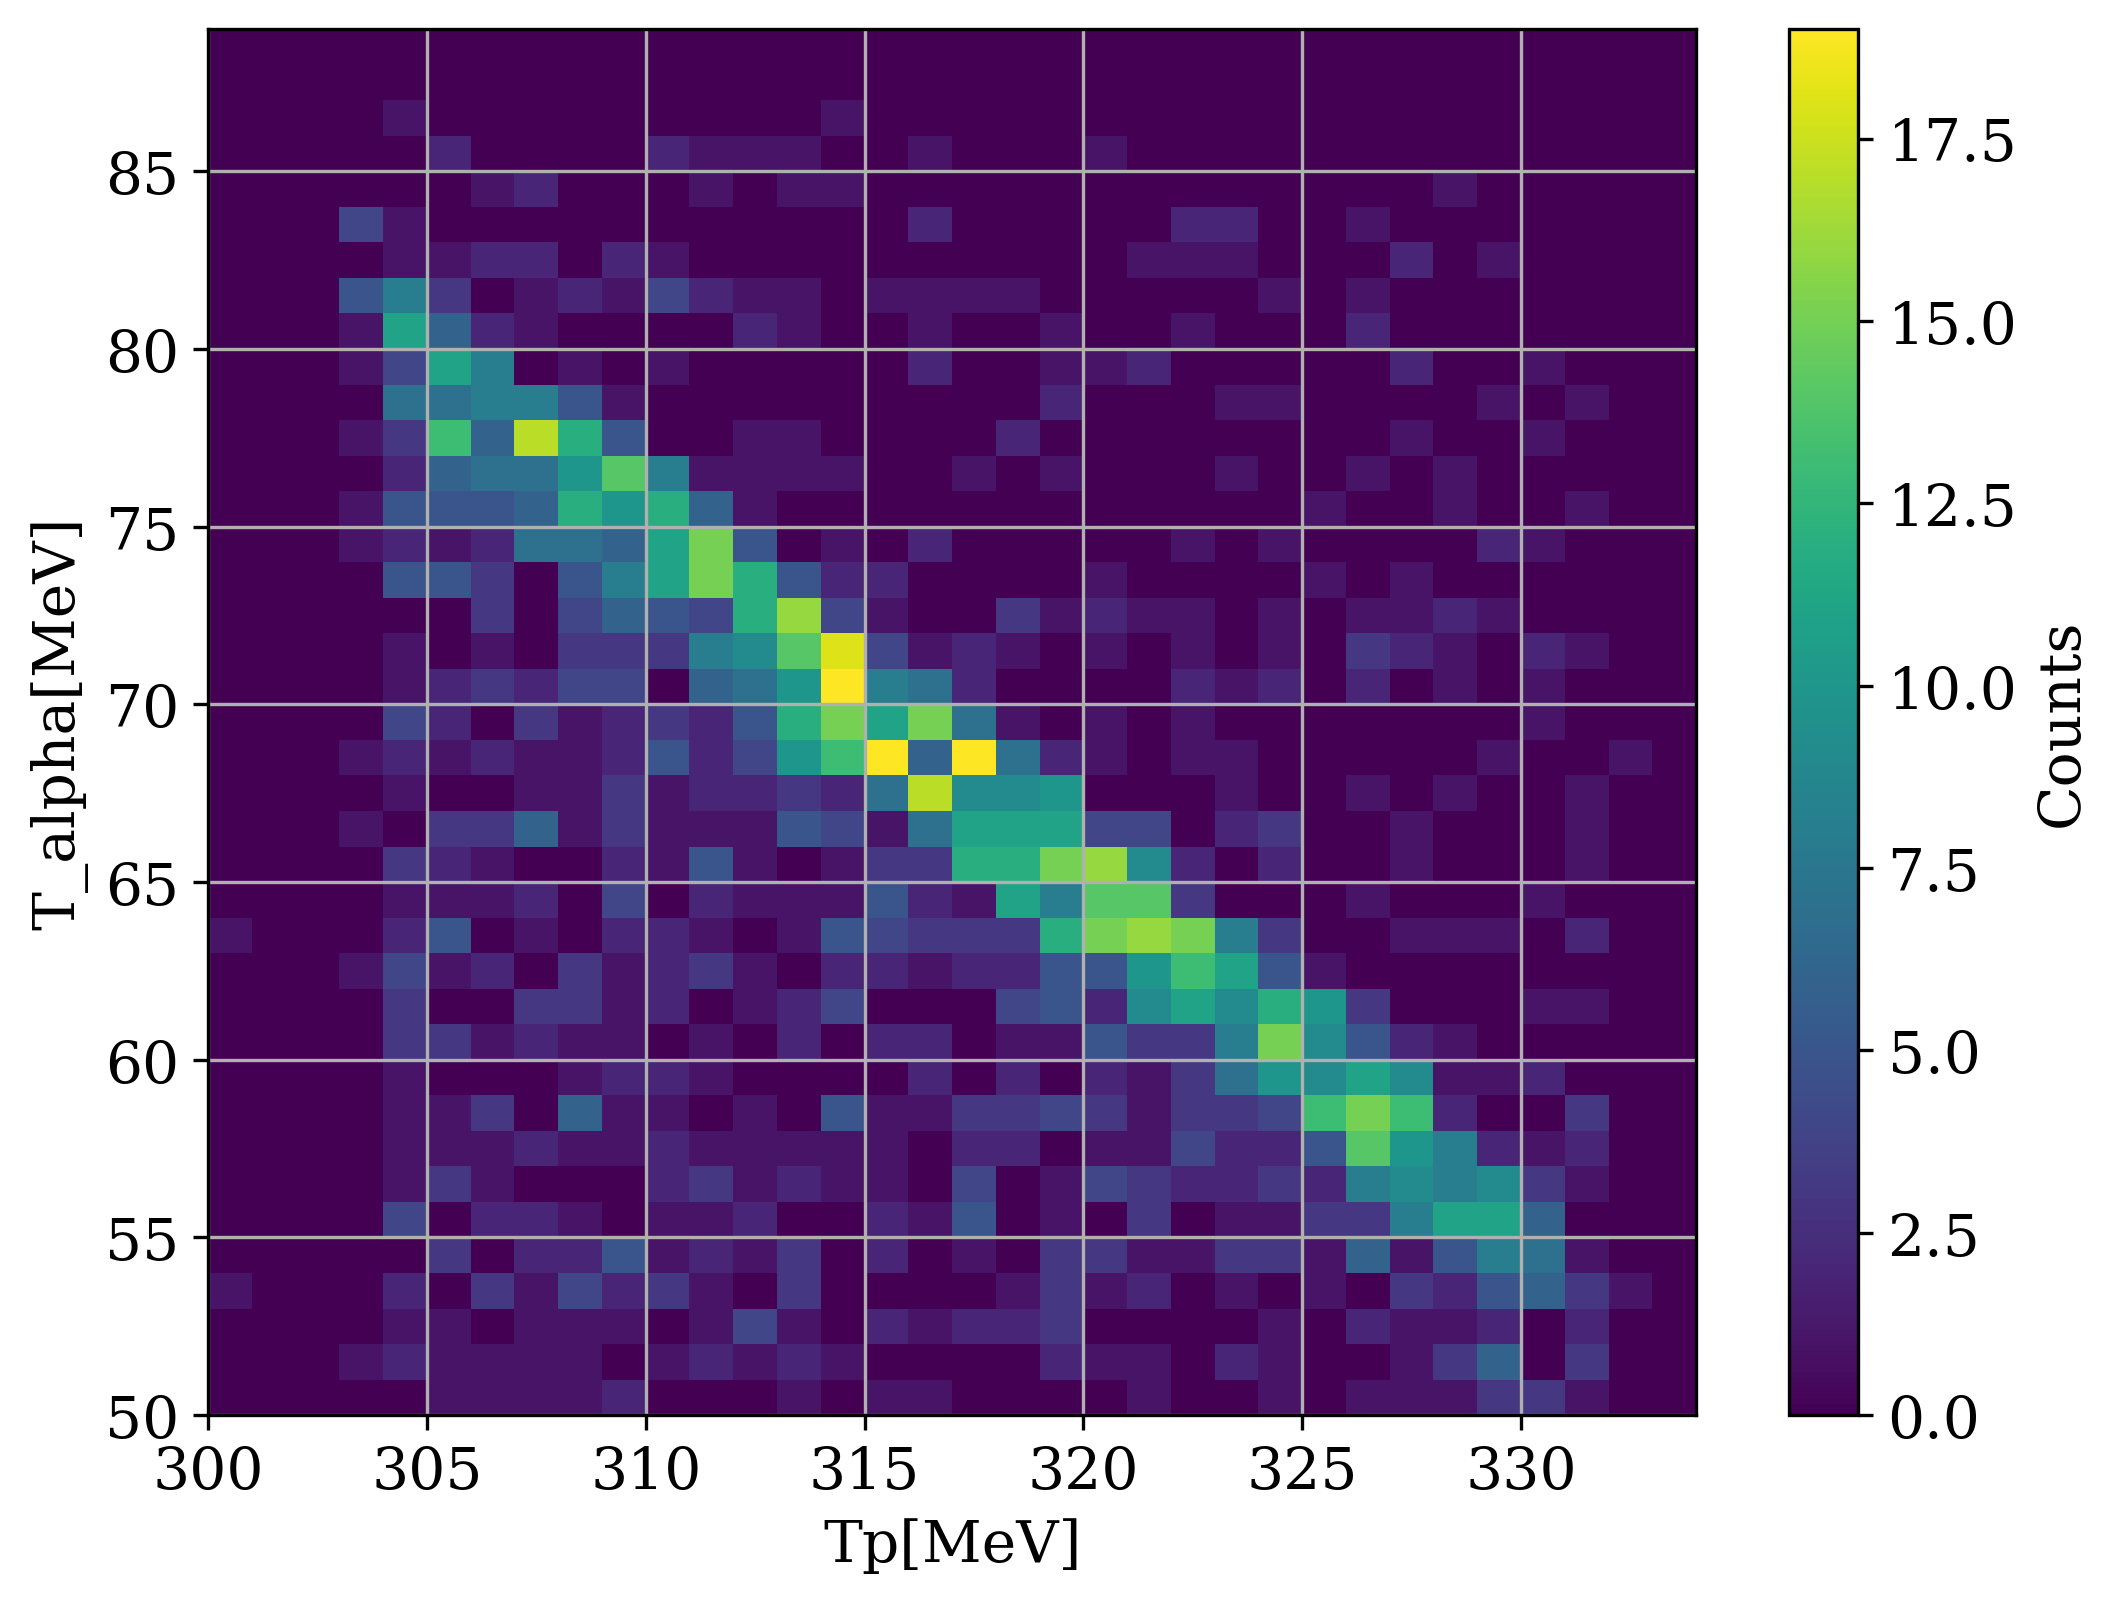

In [19]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Tp
y_axis_variable=T_alpha
# #hist range
x_axis_range_min = 300
x_axis_range_max = 335
y_axis_range_min = 50
y_axis_range_max = 90
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('Tp[MeV]')
ax.set_ylabel('T_alpha[MeV]')
ax.grid()

Text(0, 0.5, 'counts')

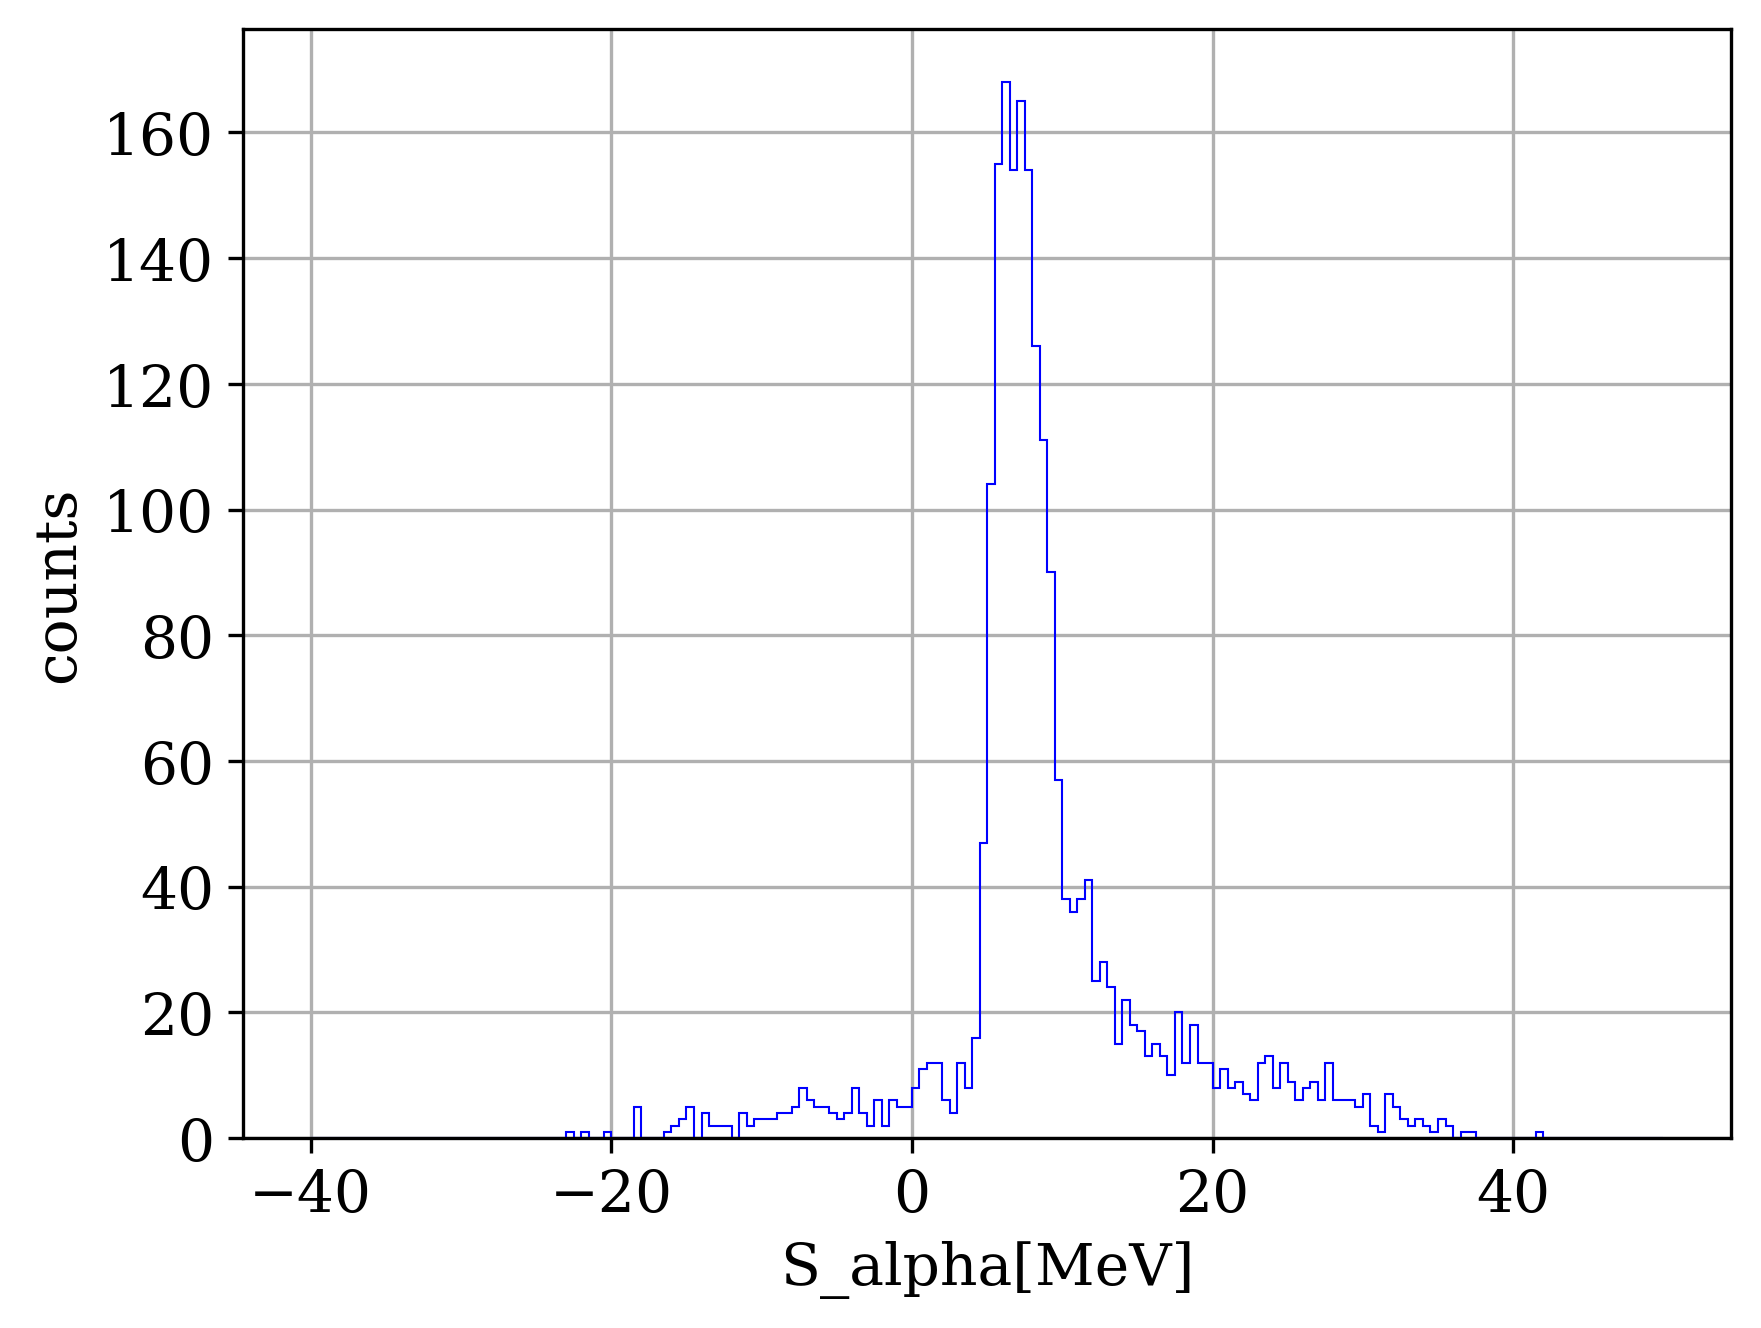

In [20]:
variables = S_alpha

#hist range
range_min=-40
range_max=50

#bin width
x_bin_width=0.5

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha[MeV]')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 619.949 ± 54.657
Mean: 7.264 ± 0.205
Sigma: 2.005 ± 0.203


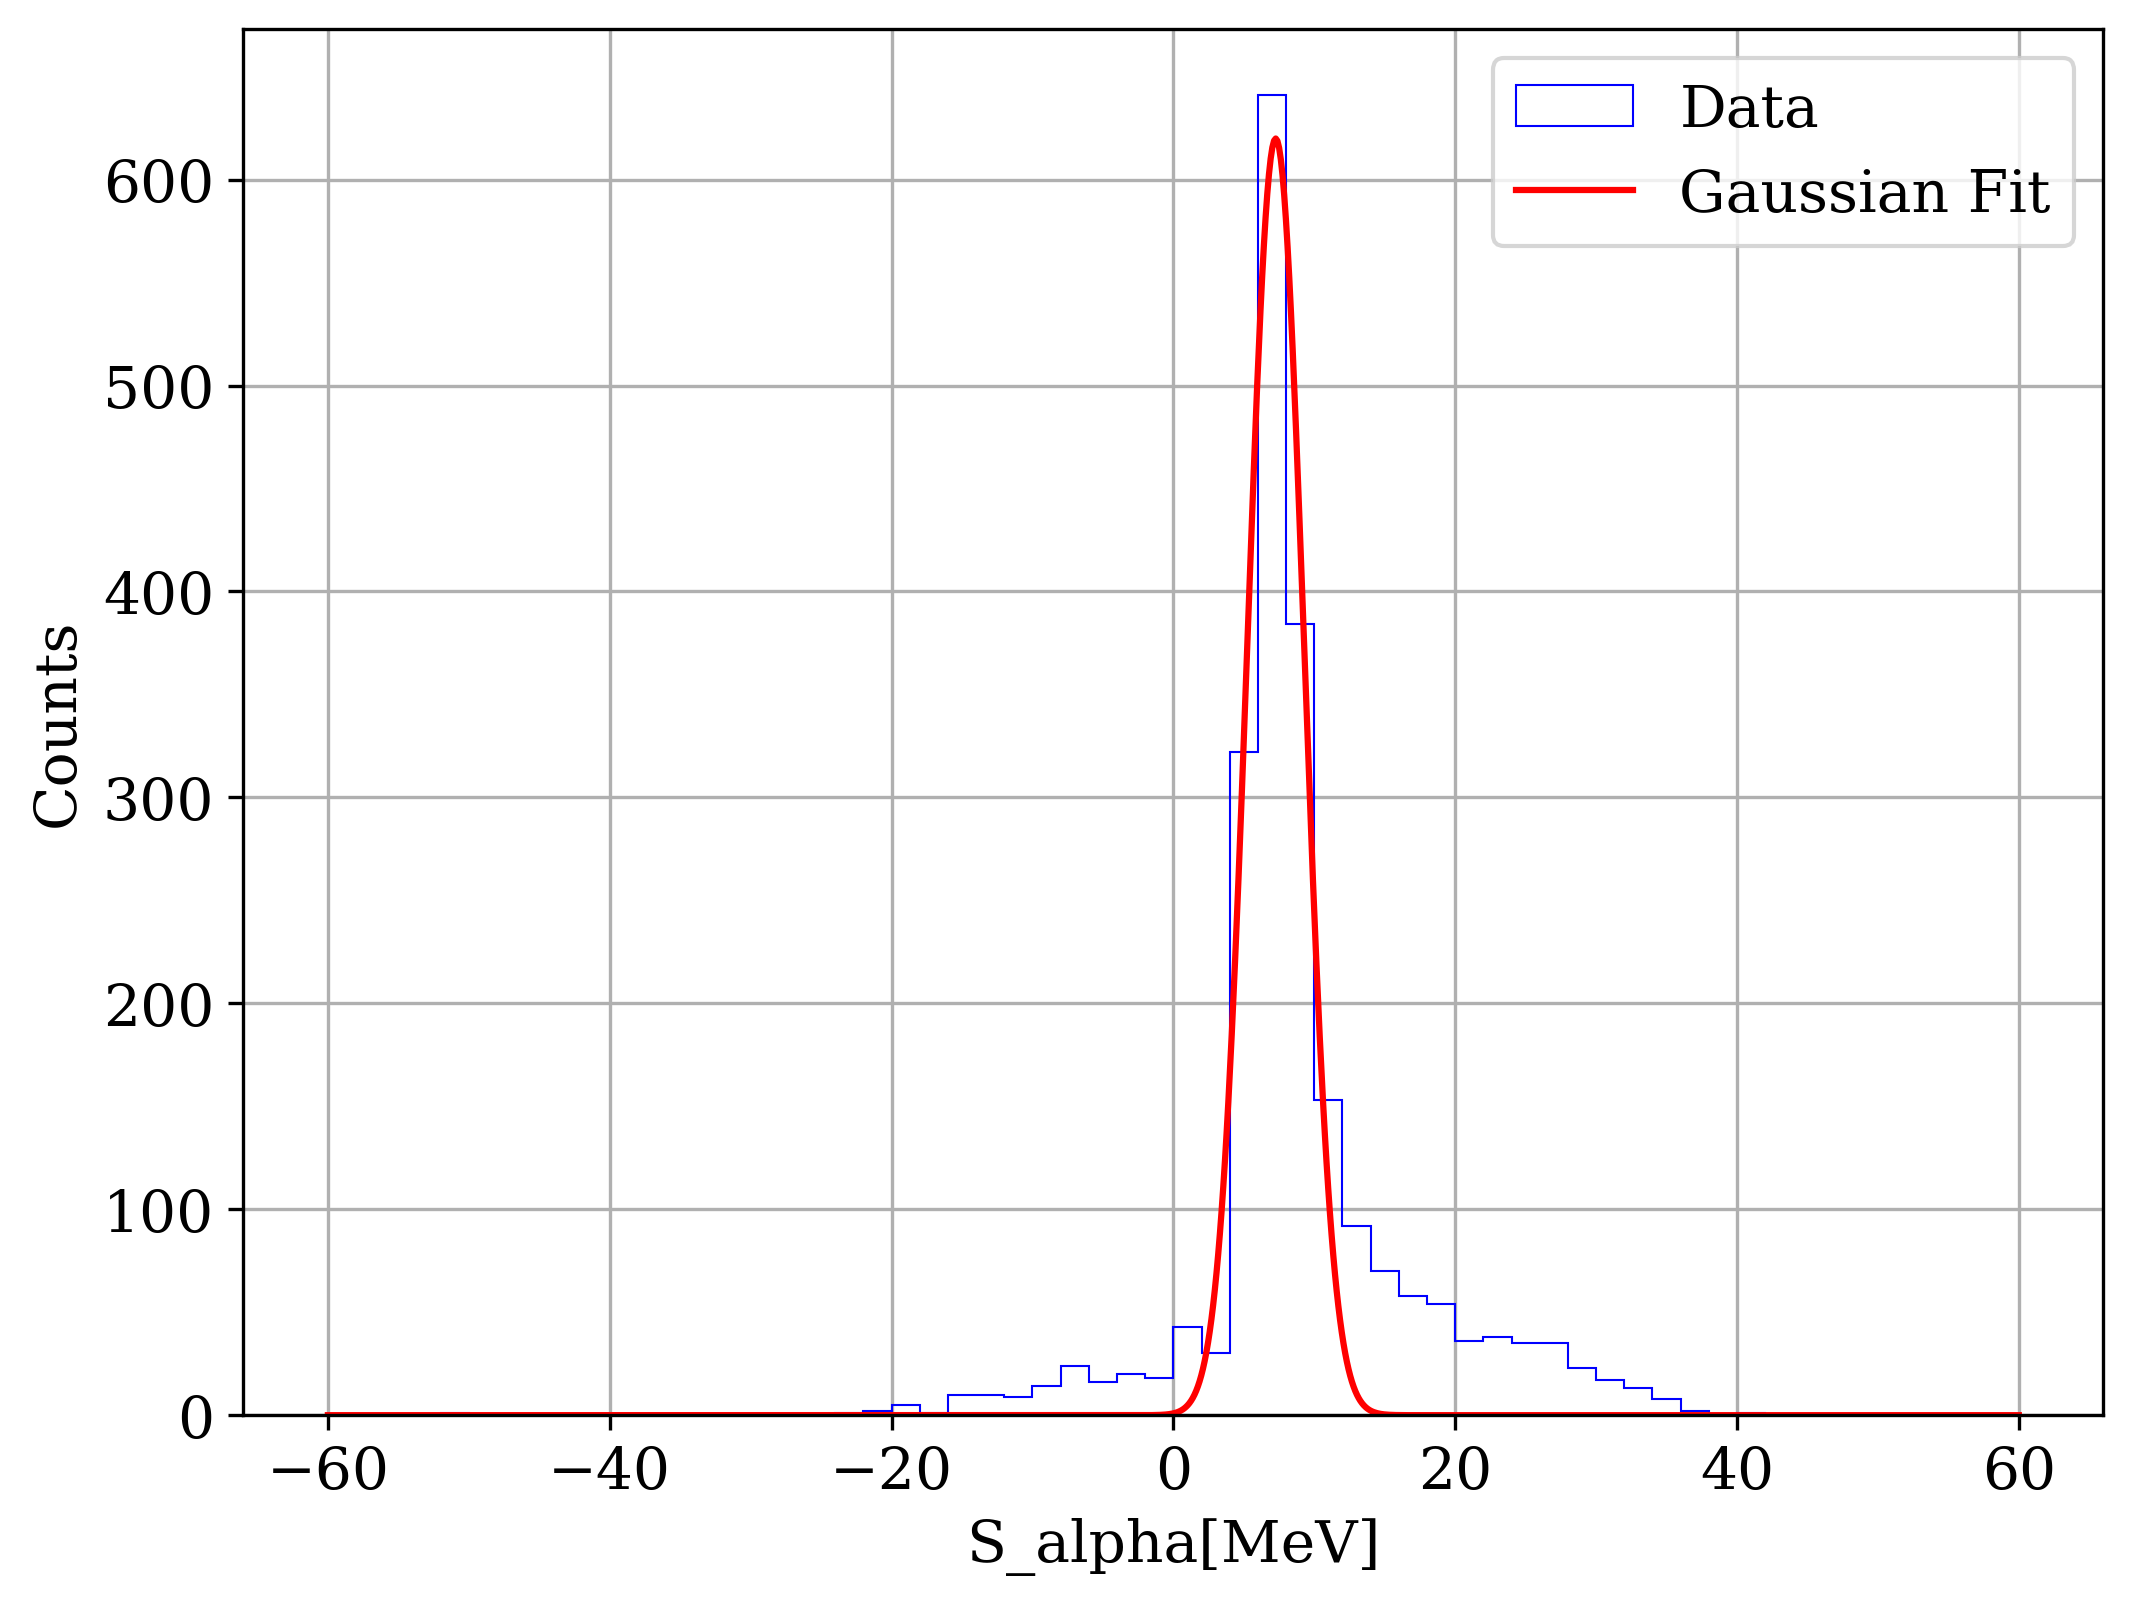

In [21]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = S_alpha
# Histogram range
hist_range_min = -60
hist_range_max = 60
# Bin width
bin_width = 2
# Fit range
fit_range_min = 0
fit_range_max = 20
# Initial parameters for the Gaussian
Amp = 175
mean = 7
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('S_alpha[MeV]')
ax.set_ylabel('Counts')
ax.legend()

In [22]:
print(len(S_alpha))

2186
